GitHub Link: https://github.com/2022583-Ahmed/CA-1-ML-2022583

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [41]:
df = pd.read_csv("student_dataV3.csv")

In [42]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171.0,1,1,122.0,1,19,12.0,...,0,0.0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254.0,1,1,160.0,1,1,3.0,...,0,6.0,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070.0,1,1,122.0,1,37,37.0,...,0,6.0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773.0,1,1,122.0,1,38,37.0,...,0,6.0,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014.0,0,1,100.0,1,37,38.0,...,0,6.0,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [43]:
df.shape

(4424, 37)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   object 
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4423 non-null   float64
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [45]:
df.isnull().sum().sort_values(ascending=False)

International                                     1
Course                                            1
Curricular units 1st sem (grade)                  1
Tuition fees up to date                           1
Curricular units 2nd sem (grade)                  1
Debtor                                            1
Father's qualification                            1
Curricular units 2nd sem (enrolled)               1
Admission grade                                   1
Curricular units 2nd sem (credited)               0
Curricular units 1st sem (evaluations)            0
Curricular units 1st sem (approved)               0
Curricular units 1st sem (without evaluations)    0
Marital status                                    0
Curricular units 1st sem (enrolled)               0
Curricular units 2nd sem (approved)               0
Curricular units 2nd sem (without evaluations)    0
Unemployment rate                                 0
Inflation rate                                    0
GDP         

In [46]:
df.duplicated().sum()

0

In [47]:
df["Target"].value_counts()

Target
Graduate    2207
Dropout     1419
Enrolled     794
Grad           1
graduate       1
Drop           1
dropout        1
Name: count, dtype: int64

In [48]:
df["Target"].value_counts(normalize=True) * 100

Target
Graduate    49.886980
Dropout     32.075045
Enrolled    17.947559
Grad         0.022604
graduate     0.022604
Drop         0.022604
dropout      0.022604
Name: proportion, dtype: float64

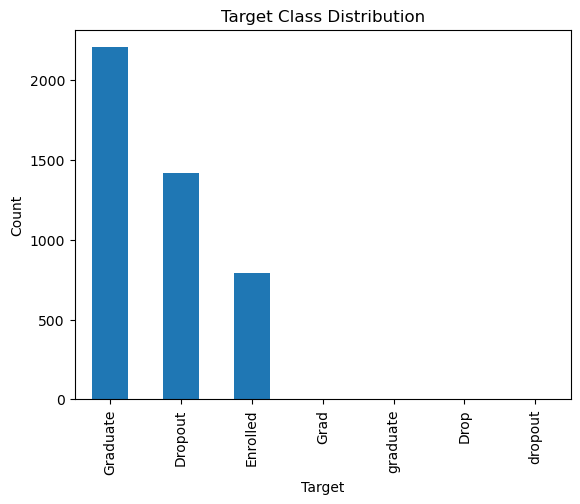

In [49]:
df["Target"].value_counts().plot(kind="bar")
plt.title("Target Class Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

In [50]:
df.describe()

,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4423.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4423.000000,4424.000000,...,4424.000000,4424.000000,4423.000000,4424.000000,4424.000000,4423.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,18.669078,1.727848,8856.458738,0.890823,4.577758,132.613314,1.873192,19.561935,22.271987,10.960895,...,0.137658,0.541817,6.231743,8.063291,4.435805,10.229941,0.150316,11.566139,1.228029,0.001969
std,17.484682,1.313793,2063.763479,0.311897,10.216592,13.188332,6.914514,15.603186,15.343244,26.418253,...,0.690880,1.918546,2.196038,3.947951,3.014764,5.211367,0.753774,2.663850,1.382711,2.269935
min,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,4.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,5.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,9.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,194.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [51]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Remove target if encoded as object later
if "Target" in numerical_cols:
    numerical_cols.remove("Target")

print(numerical_cols)

['Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Educational special needs', 'Debtor', 'Gender', 'Scholarship holder', 'International', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP']


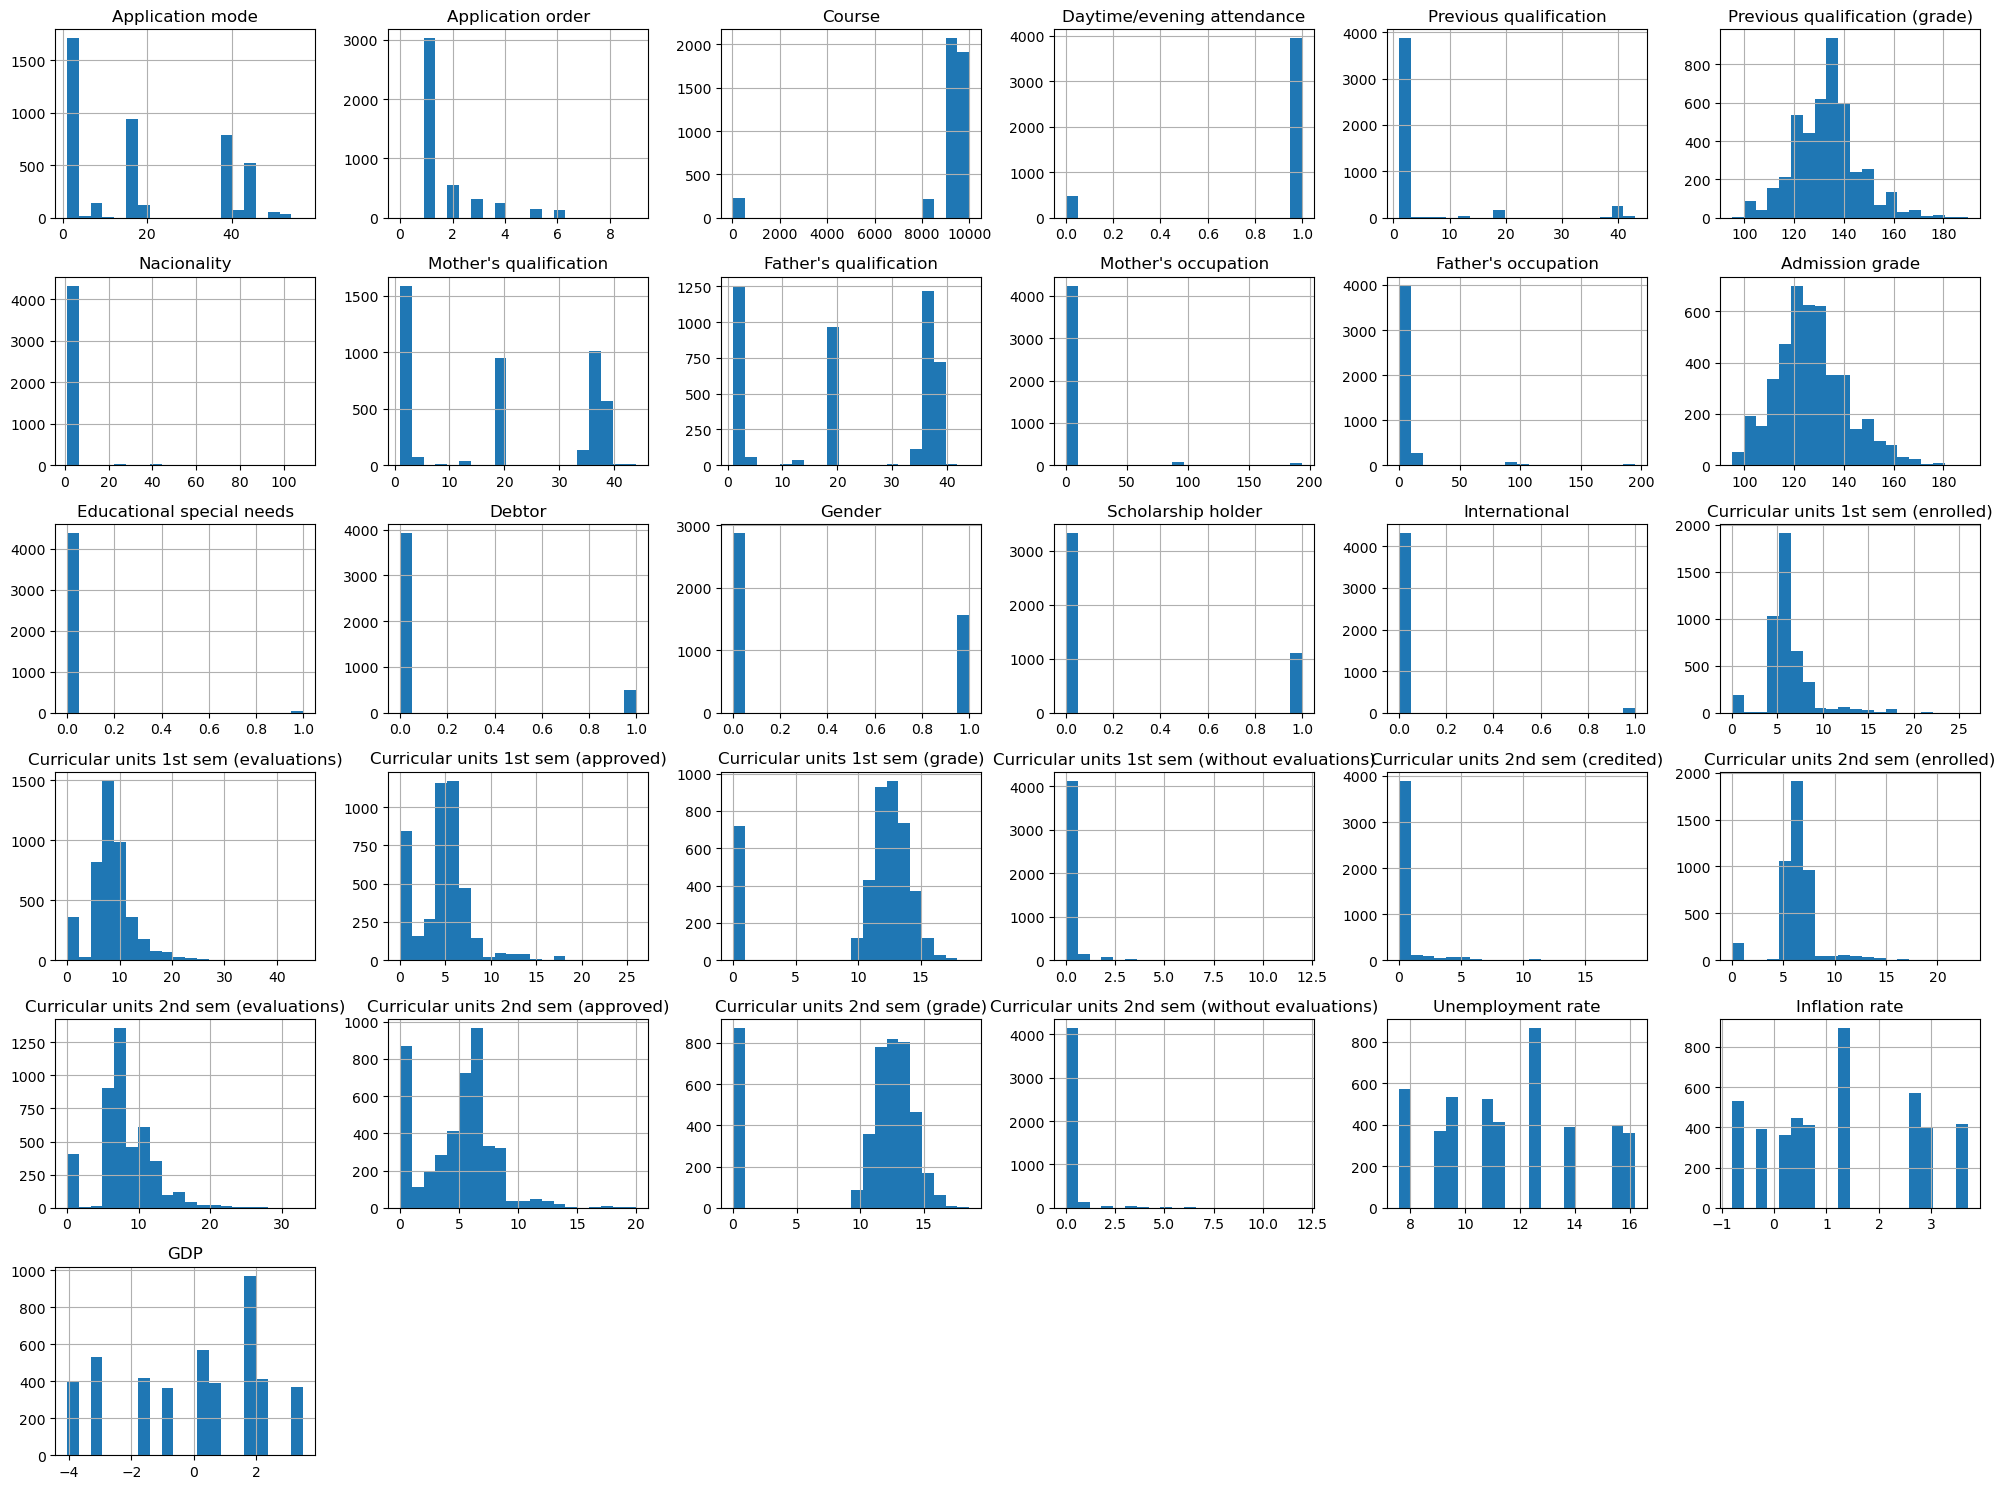

In [52]:
df[numerical_cols].hist(figsize=(20, 15), bins=20)
plt.tight_layout()
plt.show()

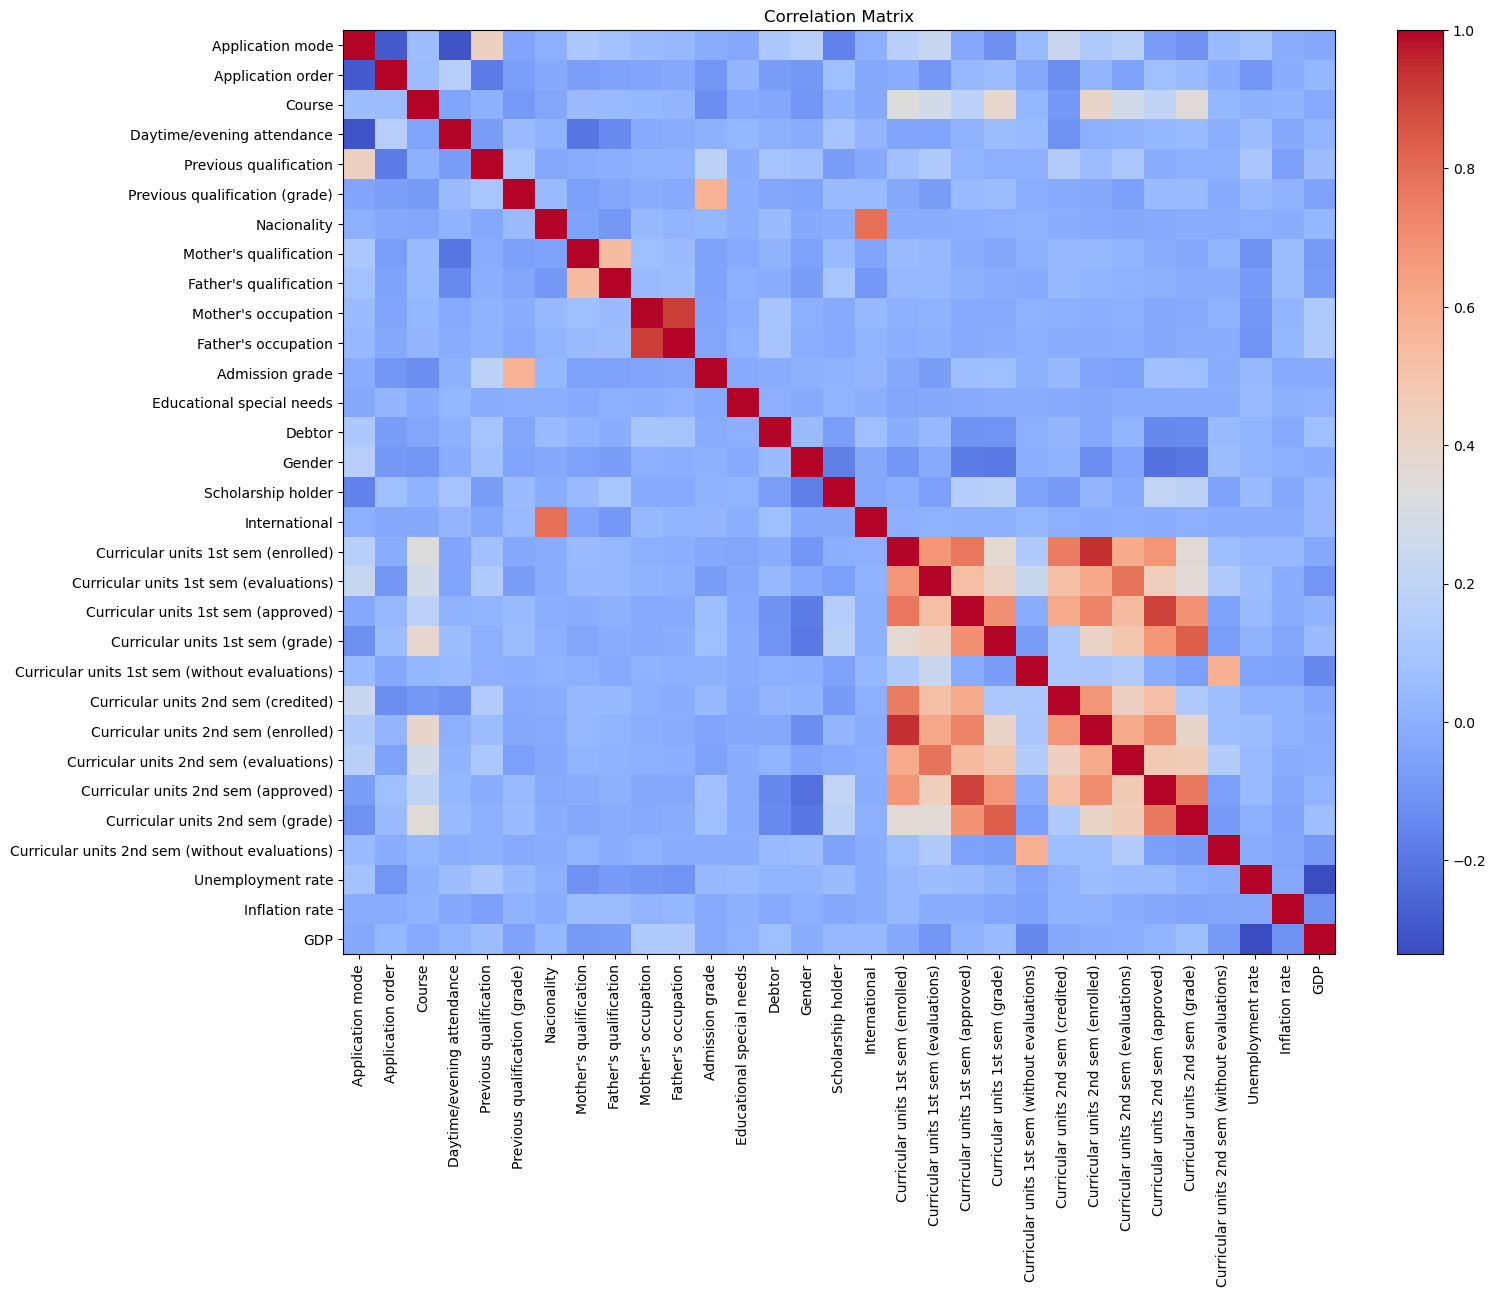

In [53]:
corr = df[numerical_cols].corr()

plt.figure(figsize=(16, 12))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

In [54]:
df.groupby("Target")[numerical_cols].mean()

,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
Target,,,,,,,,,,,,,,,,,,,,,
Drop,43.000000,1.000000,9991.000000,0.000000,3.000000,140.000000,1.000000,37.000000,19.000000,9.000000,...,0.000000,3.000000,9.000000,18.000000,8.000000,12.222222,0.000000,16.200000,0.300000,-0.920000
Dropout,23.685694,1.593376,8753.985906,0.854827,5.315715,131.108598,1.958421,21.011980,22.680056,10.121212,...,0.192389,0.447498,5.778013,7.165610,1.933756,5.889527,0.238196,11.614729,1.286117,-0.148224
Enrolled,19.799748,1.625945,8868.811083,0.905542,4.785894,131.208438,2.079345,17.622166,20.900378,14.720403,...,0.177582,0.358942,5.938287,9.435768,4.057935,11.117364,0.187657,11.272544,1.211713,0.053287
Grad,18.000000,1.000000,9500.000000,1.000000,1.000000,115.000000,1.000000,38.000000,37.000000,5.000000,...,0.000000,0.000000,8.000000,9.000000,7.000000,12.330000,0.000000,15.500000,2.800000,-4.060000
Graduate,15.005890,1.851835,8916.490027,0.908926,4.033983,134.093203,1.745809,19.294971,22.486633,10.158133,...,0.088355,0.667422,6.627380,8.141821,6.177164,12.697984,0.080652,11.638604,1.198097,0.085161
dropout,43.000000,2.000000,9853.000000,1.000000,1.000000,130.000000,1.000000,38.000000,31.000000,4.000000,...,0.000000,1.000000,6.000000,8.000000,5.000000,13.500000,0.000000,9.400000,-0.800000,-3.120000
graduate,39.000000,1.000000,9254.000000,1.000000,1.000000,130.000000,1.000000,37.000000,37.000000,4.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.800000,0.000000,9.400000,-0.800000,-3.120000


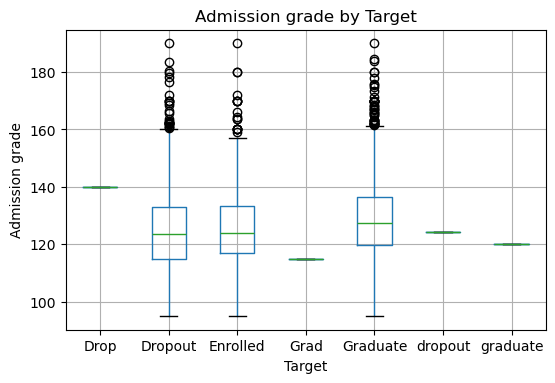

TypeError: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

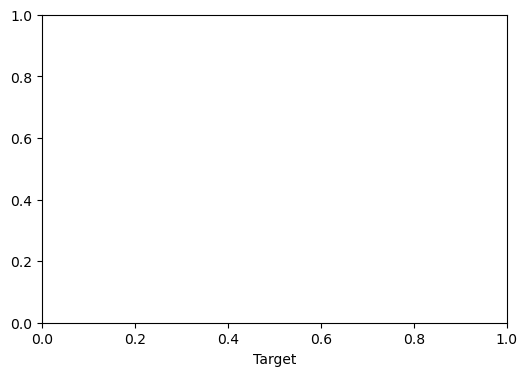

In [55]:
important_features = [
    "Admission grade",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)"
]

for col in important_features:
    if col in df.columns:
        df.boxplot(column=col, by="Target", figsize=(6,4))
        plt.title(f"{col} by Target")
        plt.suptitle("")
        plt.xlabel("Target")
        plt.ylabel(col)
        plt.show()

In [56]:
X = df.drop("Target", axis=1)
y = df["Target"]

In [57]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Class mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name} -> {i}")

Class mapping:
Drop -> 0
Dropout -> 1
Enrolled -> 2
Grad -> 3
Graduate -> 4
dropout -> 5
graduate -> 6


In [58]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['Marital status', 'Displaced', 'Tuition fees up to date', 'Age at enrollment', 'Curricular units 1st sem (credited)']
Numerical columns: ['Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Educational special needs', 'Debtor', 'Gender', 'Scholarship holder', 'International', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflat

In [60]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.2, 
    random_state=42
)

In [61]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (3539, 36)
X_test shape: (885, 36)
